# Shard


## Decompose complex multi-sensor continuous-time datasets into one-sensor-single-profile NetCDF files


The cell below executes on the main purpose of this notebook.


### Shard a collection of source files into redux profile files


Convert a particular sensor dataset
(buried in a large NetCDF file, continuous rather than profile-oriented) to a 
set of shard files sorted by year `YYYY` in directory `reduxYYYY`.


In [5]:
import pandas as pd
import xarray as xr
from pathlib import Path
import numpy as np

def get_input_with_default(prompt, default):
    """Get user input with default value."""
    response = input(f"{prompt} ").strip().lower()
    return response if response else default

def load_profile_indices(year):
    """Load profile indices for given year."""
    profile_file = Path(f"~/ooi/profileIndices/RS01SBPS_profiles_{year}.csv").expanduser()
    if not profile_file.exists():
        return None
    return pd.read_csv(profile_file)

# Sensor mapping: input variable -> (output variable name, direction)
# direction: 'ascent' = start to peak, 'descent' = peak to end
SENSOR_MAP = {
    'sea_water_temperature': ('temperature', 'ascent'),
    'sea_water_practical_salinity': ('salinity', 'ascent'),
    'sea_water_density': ('density', 'ascent'),
    'corrected_dissolved_oxygen': ('dissolvedoxygen', 'ascent'),
    'fluorometric_cdom': ('cdom', 'ascent'),
    'fluorometric_chlorophyll_a': ('chlora', 'ascent'),
    'optical_backscatter': ('backscatter', 'ascent'),
    'ph_seawater': ('ph', 'descent'),
    'pco2_seawater': ('pco2', 'descent'),
    'salinity_corrected_nitrate': ('nitrate', 'ascent'),
    'par_counts_output': ('par', 'ascent'),
    'corrected_dissolved_oxygen': ('dissolvedoxygen', 'ascent')
}

# Instrument configuration: folder suffix -> file pattern
INSTRUMENTS = {
    'ctd': 'CTDPF',
    'flor': 'FLORT',
    'ph': 'PHSEN',
    'pco2': 'PCO2W',
    'nitr': 'NUTNR',
    'par': 'PARAD'
}

def process_multi_sensor_redux(instrument='ctd'):
    """Process source files for multiple sensor types."""

    if instrument not in INSTRUMENTS:
        print(f"Unknown instrument: {instrument}")
        return

    file_pattern = INSTRUMENTS[instrument]

    # Determine which sensors to process based on instrument
    if instrument == 'ctd':
        active_sensors = {k: v for k, v in SENSOR_MAP.items() if v[0] in ['temperature', 'salinity', 'density', 'dissolvedoxygen']}
    elif instrument == 'flor':
        active_sensors = {k: v for k, v in SENSOR_MAP.items() if v[0] in ['cdom', 'chlora', 'backscatter']}
    elif instrument == 'ph':
        active_sensors = {k: v for k, v in SENSOR_MAP.items() if v[0] in ['ph']}
    elif instrument == 'pco2':
        active_sensors = {k: v for k, v in SENSOR_MAP.items() if v[0] in ['pco2']}
    elif instrument == 'nitr':
        active_sensors = {k: v for k, v in SENSOR_MAP.items() if v[0] in ['nitrate']}
    elif instrument == 'par':
        active_sensors = {k: v for k, v in SENSOR_MAP.items() if v[0] in ['par']}
    else:
        active_sensors = SENSOR_MAP

    # Scan for source folders
    base_folder = Path("~/ooi/ooinet/rca/SlopeBase/scalar").expanduser()

    print(f"Scanning for {instrument} source folders...")
    available_years = []
    for year in range(2014, 2027):
        source_folder = base_folder / f"{year}_{instrument}"
        if source_folder.exists():
            file_count = len(list(source_folder.glob(f"*{file_pattern}*.nc")))
            if file_count > 0:
                print(f"  {year}_{instrument}: {file_count} files")
                response = get_input_with_default(f"    Process {year}? [y/n] (default y):", "y")
                if response == 'y':
                    available_years.append(year)

    if not available_years:
        print("No years selected")
        return

    print(f"\nSelected years: {available_years}")

    # Create output directories
    for year in range(2014, 2027):
        output_dir = Path(f"~/ooi/redux/redux{year}").expanduser()
        output_dir.mkdir(exist_ok=True)

    # Statistics
    stats = {sensor[0]: {'attempted': 0, 'written': 0, 'skipped': 0} for sensor in active_sensors.values()}

    # Process each year
    for folder_year in available_years:
        source_folder = base_folder / f"{folder_year}_{instrument}"
        source_files = sorted(list(source_folder.glob(f"*{file_pattern}*.nc")))

        print(f"\n=== Processing {folder_year}_{instrument} ({len(source_files)} files) ===")

        for file_idx, file_path in enumerate(source_files, 1):
            if file_idx % 5 == 0:
                print(f"  File {file_idx}/{len(source_files)}")

            try:
                ds = xr.open_dataset(file_path)
                ds = ds.swap_dims({'obs': 'time'})

                start_time = pd.to_datetime(ds.time.values[0])
                end_time = pd.to_datetime(ds.time.values[-1])

                # Process each year in the file
                for year in range(start_time.year, end_time.year + 1):
                    profiles_df = load_profile_indices(year)
                    if profiles_df is None:
                        continue

                    daily_profiles = {}

                    for _, profile_row in profiles_df.iterrows():
                        profile_index = profile_row['profile']
                        start_str = profile_row['start']
                        peak_str = profile_row['peak']
                        end_str = profile_row['end']

                        start_time_profile = pd.to_datetime(start_str)
                        peak_time_profile = pd.to_datetime(peak_str)
                        end_time_profile = pd.to_datetime(end_str)

                        # Track daily profile sequence
                        date_key = start_time_profile.date()
                        if date_key not in daily_profiles:
                            daily_profiles[date_key] = 0
                        daily_profiles[date_key] += 1
                        daily_sequence = daily_profiles[date_key]

                        # Process each sensor type
                        for input_var, (output_var, direction) in active_sensors.items():
                            stats[output_var]['attempted'] += 1

                            # Determine time slice based on direction
                            if direction == 'ascent':
                                slice_start = start_time_profile
                                slice_end = peak_time_profile
                            else:  # descent
                                slice_start = peak_time_profile
                                slice_end = end_time_profile

                            try:
                                profile_data = ds.sel(time=slice(slice_start, slice_end))

                                if len(profile_data.time) == 0:
                                    continue

                                # Check if variable exists in data
                                if input_var not in profile_data.data_vars:
                                    continue

                                # Determine output folder based on profile year
                                profile_year = start_time_profile.year
                                output_dir = Path(f"~/ooi/redux/redux{profile_year}").expanduser()
                                julian_day = start_time_profile.timetuple().tm_yday

                                # Generate filename
                                filename = f"RCA_sb_sp_{output_var}_{profile_year}_{julian_day:03d}_{profile_index}_{daily_sequence}_V1.nc"
                                output_path = output_dir / filename

                                # Skip if file already exists
                                if output_path.exists():
                                    stats[output_var]['skipped'] += 1
                                    continue

                                # Create dataset with renamed variable
                                sensor_ds = xr.Dataset({
                                    output_var: profile_data[input_var]
                                })

                                # Add depth coordinate if available
                                if 'depth' in profile_data.coords:
                                    sensor_ds = sensor_ds.assign_coords(depth=profile_data['depth'])

                                # Remove unwanted variables
                                for var in ['lat', 'lon', 'obs']:
                                    if var in sensor_ds.coords:
                                        sensor_ds = sensor_ds.drop_vars(var)
                                    if var in sensor_ds.data_vars:
                                        sensor_ds = sensor_ds.drop_vars(var)

                                # Write file
                                sensor_ds.to_netcdf(output_path)
                                stats[output_var]['written'] += 1

                            except Exception:
                                continue

            except Exception as e:
                continue

    # Print statistics
    print(f"\n=== Processing Complete ===")
    for sensor, counts in stats.items():
        print(f"\n{sensor}:")
        print(f"  Attempted: {counts['attempted']}")
        print(f"  Written: {counts['written']}")
        print(f"  Skipped (already exist): {counts['skipped']}")

    # Report files by year and sensor
    print("\n=== Files by Year ===")
    for year in range(2014, 2027):
        output_dir = Path(f"~/ooi/redux/redux{year}").expanduser()
        if output_dir.exists():
            sensor_counts = {}
            for sensor_info in active_sensors.values():
                sensor = sensor_info[0]
                count = len(list(output_dir.glob(f"*_{sensor}_*.nc")))
                if count > 0:
                    sensor_counts[sensor] = count

            if sensor_counts:
                print(f"\n{year}:")
                for sensor, count in sensor_counts.items():
                    print(f"  {sensor}: {count}")

# Run the sharding task
#   'ctd' for CTD sensors (4 sensors: temperature, salinity, density, dissolvedoxygen - all ascent)
#   'flor' for fluorometer (3 sensors: cdom, chlora, backscatter - all ascent)
#   'ph' for pH (1 sensor: ph - descent)
#   'pco2' for pCO2 (1 sensor: pco2 - descent)
#   'nitr' for nitrate (1 sensor: nitrate - ascent)
#   'par' for PAR (1 sensor: par - ascent)
process_multi_sensor_redux('ph')

Scanning for ph source folders...
  2015_ph: 2 files


    Process 2015? [y/n] (default y):  n


  2016_ph: 1 files


    Process 2016? [y/n] (default y):  


  2017_ph: 1 files


...

  2024_ph: 1 files


    Process 2024? [y/n] (default y):  


  2025_ph: 1 files


    Process 2025? [y/n] (default y):  



Selected years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

=== Processing 2016_ph (1 files) ===

=== Processing 2017_ph (1 files) ===

=== Processing 2018_ph (2 files) ===

=== Processing 2019_ph (1 files) ===

=== Processing 2020_ph (1 files) ===

=== Processing 2021_ph (1 files) ===

=== Processing 2022_ph (1 files) ===

=== Processing 2023_ph (1 files) ===

=== Processing 2024_ph (1 files) ===

=== Processing 2025_ph (1 files) ===

=== Processing Complete ===

ph:
  Attempted: 39138
  Written: 15368
  Skipped (already exist): 0

=== Files by Year ===

2015:
  ph: 410

2016:
  ph: 2300

2017:
  ph: 938

2018:
  ph: 1314

2019:
  ph: 2075

2020:
  ph: 1175

2021:
  ph: 2628

2022:
  ph: 2136

2023:
  ph: 416

2024:
  ph: 2033

2025:
  ph: 1367


## Inspect source files and shard files

In [8]:
import xarray as xr
d = xr.open_dataset('/home/rob/redux2022/RCA_sb_sp_ph_2022_331_15377_1_V1.nc')
d

<xarray.Dataset>
Dimensions:  (time: 1)
Coordinates:
  * time     (time) datetime64[ns] 2022-11-27T02:06:51.473237504
Data variables:
    depth    (time) float64 ...
    ph       (time) float64 ...

In [4]:
!ls ~/ooi/ooinet/rca/SlopeBase/scalar/2017_ph

deployment0004_RS01SBPS-SF01A-2D-PHSENA101-streamed-phsen_data_record_20170804T210000.369097-20180321T000000.623145.nc


In [11]:
import xarray as xr
d = xr.open_dataset('~/ooi/ooinet/rca/SlopeBase/scalar/2022_ph/deployment0010_RS01SBPS-SF01A-2D-PHSENA101-streamed-phsen_data_record_20220916T083953.847069-20221206T195550.204456.nc')
d = d.swap_dims({'obs': 'time'})

d

<xarray.Dataset>
Dimensions:                             (time: 2387,
                                         ph_light_measurements_dim_0: 92,
                                         signal_intensity_578_dim_0: 23,
                                         reference_light_measurements_dim_0: 16,
                                         signal_intensity_434_dim_0: 23)
Coordinates:
    obs                                 (time) int32 0 1 2 3 ... 2384 2385 2386
  * signal_intensity_578_dim_0          (signal_intensity_578_dim_0) int32 0 ...
  * reference_light_measurements_dim_0  (reference_light_measurements_dim_0) int32 ...
  * ph_light_measurements_dim_0         (ph_light_measurements_dim_0) int32 0...
    lon                                 (time) float64 ...
    lat                                 (time) float64 ...
  * signal_intensity_434_dim_0          (signal_intensity_434_dim_0) int32 0 ...
    depth                               (time) float64 ...
  * time                                (time) datetime64[ns] 2022-09-16T08:3...
Data variables: (12/28)
    ph_light_measurements               (time, ph_light_measurements_dim_0) float32 ...
    ph_seawater_qartod_results          (time) uint8 ...
    phsen_thermistor_temperature        (time) float64 ...
    phsen_battery_volts                 (time) float64 ...
    record_type                         (time) float32 ...
    ph_seawater_qartod_executed         (time) object ...
    ...                                  ...
    preferred_timestamp                 (time) object ...
    int_ctd_pressure                    (time) float64 ...
    record_time                         (time) datetime64[ns] ...
    checksum                            (time) float32 ...
    reference_light_measurements        (time, reference_light_measurements_dim_0) float32 ...
    unique_id                           (time) float32 ...
Attributes: (12/55)
    node:                            SF01A
    comment:                         
    publisher_email:                 
    sourceUrl:                       http://oceanobservatories.org/
    collection_method:               streamed
    stream:                          phsen_data_record
    ...                              ...
    geospatial_lon_max:              -125.389591
    geospatial_lon_units:            degrees_east
    geospatial_lon_resolution:       0.1
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  0.1
    geospatial_vertical_positive:    down

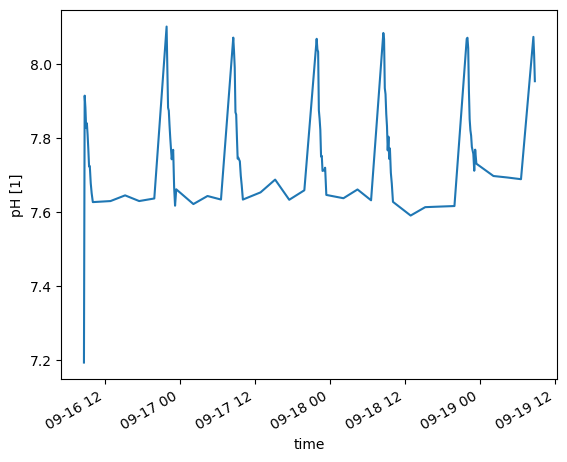

In [15]:
d.ph_seawater[0:100].plot()

## Paused: Profile tracking


For a fixed site + year (example: Oregon Slope Base, 2016) create a metadata file tracking presence/absence
of the possible profiles: Quantity 365 * 9 profiles + 9 more in leap years. This is a record of what data are
actually present in the data system. This can be done from `profileIndices` but the actual yield in the `reduxYYYY`
folders is in some cases less; so work from the shard inventory. 

In [ ]:
This code intentionally disabled until revisited with intent.

"""
Generate CSV file tracking CTD temperature profile status for OOI RCA Slope Base shallow profiler.
Creates rca_sb_ctd_temp_profile_status.csv with daily profile availability (2014-2025).
"""

import csv
import datetime
from pathlib import Path

def is_leap_year(year):
    """Check if year is a leap year."""
    return year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)

def get_days_in_year(year):
    """Get number of days in year."""
    return 366 if is_leap_year(year) else 365

def julian_to_date(year, julian_day):
    """Convert Julian day to dd-MON-yyyy format."""
    date = datetime.datetime(year, 1, 1) + datetime.timedelta(days=julian_day - 1)
    return date.strftime("%d-%b-%Y").upper()

def generate_profile_status_csv():
    """Generate the profile status CSV file."""
    
    output_file = Path("rca_sb_ctd_temp_profile_status.csv")
    
    # Define year range
    start_year = 2014
    end_year = 2025
    
    # Column headers
    headers = ['year', 'julian_day', 'date', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'Total', 'Noon', 'Midnight']
    
    total_days = 0
    total_profiles = 0
    
    with open(output_file, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        
        # Write headers
        writer.writerow(headers)
        
        # Generate rows for each year
        for year in range(start_year, end_year + 1):
            days_in_year = get_days_in_year(year)
            
            for julian_day in range(1, days_in_year + 1):
                date_str = julian_to_date(year, julian_day)
                
                # Initialize profile columns (1-9) as 0 (will be populated when processing actual data)
                profiles = [0] * 9
                
                # Calculate totals
                total_profiles_day = sum(profiles)
                
                # Placeholder values for noon and midnight profile indices
                noon_profile = 0  # Will be determined from actual profile timing
                midnight_profile = 0  # Will be determined from actual profile timing
                
                # Write row
                row = [year, julian_day, date_str] + profiles + [total_profiles_day, noon_profile, midnight_profile]
                writer.writerow(row)
                
                total_days += 1
                total_profiles += total_profiles_day
    
    # Print diagnostics
    print(f"Generated {output_file}")
    print(f"Total days: {total_days}")
    print(f"Date range: {start_year} - {end_year}")
    print(f"Years covered: {end_year - start_year + 1}")
    print(f"Current mean profiles per day: {total_profiles / total_days:.2f}")
    print(f"Expected profiles per day when populated: 9")
    print(f"File ready for population with actual profile data")

if __name__ == "__main__":
    generate_profile_status_csv()

## Paused: Profile update


Update the profile status program, write extracted profile files, create a timeline file 

In [ ]:
File intentionally disabled

"""
Extract individual temperature profiles from CTD NetCDF files to redux files.
"""

import pandas as pd
import xarray as xr
from pathlib import Path

def analyze_source_file(netcdf_file):
    """Analyze source NetCDF file time range and estimate profiles."""
    
    ds = xr.open_dataset(netcdf_file)
    ds = ds.swap_dims({'obs': 'time'})
    
    start_time = pd.to_datetime(ds.time.values[0])
    end_time = pd.to_datetime(ds.time.values[-1])
    
    time_range_days = (end_time - start_time).days + 1
    estimated_profiles = time_range_days * 9
    
    print(f"=== SOURCE FILE ANALYSIS ===")
    print(f"File: {netcdf_file}")
    print(f"Start time: {start_time}")
    print(f"End time: {end_time}")
    print(f"Time range: {time_range_days} days")
    print(f"Estimated profiles (9/day): {estimated_profiles}")
    print(f"================================\n")
    
    return ds, start_time, end_time

def load_profile_indices(year):
    """Load profile indices for given year."""
    profile_file = Path(f"~/ooi/profileIndices/RS01SBPS_profiles_{year}.csv").expanduser()
    if not profile_file.exists():
        return None
    return pd.read_csv(profile_file)

def extract_profiles(ds, start_time, end_time, output_dir):
    """Extract temperature profiles from NetCDF dataset."""
    
    attempted = 0
    successful = 0
    
    for year in range(start_time.year, end_time.year + 1):
        profiles_df = load_profile_indices(year)
        if profiles_df is None:
            print(f"No profile indices for {year}")
            continue
            
        daily_profiles = {}
        
        for _, profile_row in profiles_df.iterrows():
            attempted += 1
            
            profile_index = profile_row['profile']
            start_str = profile_row['start']
            peak_str = profile_row['peak']
            
            start_time_profile = pd.to_datetime(start_str)
            peak_time_profile = pd.to_datetime(peak_str)
            
            # Track daily profile sequence
            date_key = start_time_profile.date()
            if date_key not in daily_profiles:
                daily_profiles[date_key] = 0
            daily_profiles[date_key] += 1
            daily_sequence = daily_profiles[date_key]
            
            try:
                profile_data = ds.sel(time=slice(start_time_profile, peak_time_profile))
                
                if len(profile_data.time) == 0:
                    continue
                    
                # Check for sea_water_temperature data
                if 'sea_water_temperature' not in profile_data.data_vars:
                    continue
                
                # Create temperature dataset (rename variable)
                temp_ds = xr.Dataset({
                    'temperature': profile_data['sea_water_temperature']
                })
                
                # Add depth coordinate if available
                if 'depth' in profile_data.coords:
                    temp_ds = temp_ds.assign_coords(depth=profile_data['depth'])
                
                # Generate filename: AAA_SSS_TTT_BBB_YYYY_DDD_PPPP_Q_VVVV.nc
                julian_day = start_time_profile.timetuple().tm_yday
                filename = f"RCA_OSB_Profiler_Temp_{year}_{julian_day:03d}_{profile_index}_{daily_sequence}_V1.nc"
                output_path = output_dir / filename
                
                # Write file
                temp_ds.to_netcdf(output_path)
                successful += 1
                
                if successful % 50 == 0:
                    print(f"Extracted {successful} profiles...")
                    
            except Exception as e:
                print(f"Error processing profile {profile_index}: {e}")
                continue
    
    return attempted, successful

def main():
    """Main processing function."""
    
    output_dir = Path("~/ooi/redux").expanduser()
    output_dir.mkdir(exist_ok=True)
    
    ctd_file = Path("~/ooi/ooinet/rca/SlopeBase/scalar/2015_2025_ctd/deployment0004_RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample_20180208T000000.840174-20180226T115959.391002.nc").expanduser()
    
    if not ctd_file.exists():
        print(f"CTD file not found: {ctd_file}")
        return
    
    # Analyze source file first
    ds, start_time, end_time = analyze_source_file(ctd_file)
    
    # Extract profiles
    attempted, successful = extract_profiles(ds, start_time, end_time, output_dir)
    
    # Print diagnostics
    print(f"\n=== EXTRACTION COMPLETE ===")
    print(f"Profiles attempted: {attempted}")
    print(f"Profiles successfully extracted: {successful}")
    print(f"Success rate: {successful/attempted*100:.1f}%" if attempted > 0 else "No profiles attempted")
    print(f"Redux files written to: {output_dir}")

if __name__ == "__main__":
    main()


## Parsing Dissolved Oxygen 


### Compare CTD dissolved oxygen (2 data variables) with DO dissolved oxygen (1 data variable)


Conclusion is that they are the same data.

In [ ]:
# Compare data variables for CTD file versus DO file
import xarray as xr

#ds = xr.open_dataset('~/ooi/redux/redux2018/RCA_sb_sp_temperature_2018_048_5440_9_V1.nc')
ds_ctd = xr.open_dataset('~/ooi/ooinet/rca/SlopeBase/scalar/2016_ctd/deployment0002_RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample_20160707T000000.194092-20160716T111049.607585.nc')
ds_do  = xr.open_dataset('~/ooi/ooinet/rca/SlopeBase/scalar/2016_ctd/deployment0002_RS01SBPS-SF01A-2A-DOFSTA102-streamed-do_fast_sample_20160511T235959.098689-20160716T120000.633855.nc')
ds_ctd.data_vars.keys()

In [ ]:
# see above
ds_do.data_vars.keys()

In [ ]:
# sanity check quick plot of temperature versus depth

This code disabled: Please verify filename in use; I think it is incorrect

"""
Plot temperature profiles with temperature on x-axis and depth on y-axis.
"""

import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
import sys

    
# Load the profile data
ds = xr.open_dataset('~/ooi/redux/redux2018/RCA_sb_sp_temperature_2018_048_5440_9_V1.nc')

# Extract temperature and depth
temperature = ds['temperature'].values
depth = ds['depth'].values

# Create the plot
plt.figure(figsize=(8, 10))
plt.plot(temperature, depth, 'b-', linewidth=2, marker='o', markersize=2)

# Set up axes
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Depth (m)', fontsize=12)
plt.ylim(200, 0)  # 200m at bottom, 0m at top
plt.grid(True, alpha=0.3)

# Add title with filename
profile_name = Path('~/ooi/redux/redux2018/RCA_sb_sp_temperature_2018_048_5440_9_V1.nc').stem
plt.title(f'Temperature Profile: {profile_name}', fontsize=14)

# Tight layout and show
plt.tight_layout()
plt.show()


### continuation of the DO comparison (on pause)


This section is a digression on whether DO files contain the same dissolved oxygen data 
as CTD files. The conclusion seems to be yes but this code requires a revisit with scrutiny.
For example it seems to revert from `time` to `obs`.

In [ ]:
Temporary disable

import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path

# Load files
ctd_dir = Path.home() / 'ooi/ooinet/rca/SlopeBase/scalar/2025_ctd'
do_dir = Path.home() / 'ooi/ooinet/rca/SlopeBase/scalar/2024_ctd'
ctd_file = ctd_dir / 'deployment0012_RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample_20250101T000000.308210-20250119T115959.698459.nc'
do_file = do_dir / 'deployment0012_RS01SBPS-SF01A-2A-DOFSTA102-streamed-do_fast_sample_20241231T235959.308203-20250507T000000.827670.nc'

ds_ctd = xr.open_dataset(ctd_file)
ds_do = xr.open_dataset(do_file)

print("CTD dimensions:", ds_ctd.dims)
print("DO dimensions:", ds_do.dims)
print("\nCTD variables:", [v for v in ds_ctd.data_vars if 'oxygen' in v.lower()])
print("DO variables:", [v for v in ds_do.data_vars if 'oxygen' in v.lower()])

# Use 'obs' dimension instead of 'time'
start_time = np.datetime64('2025-01-01T00:00:00')
time = ds_ctd.time.values
depth = ds_ctd.depth.values

# Find indices after start_time
idx_after = np.where(time >= start_time)[0]
time_after = time[idx_after]
depth_after = depth[idx_after]

# Detect ascent (depth decreasing)
depth_diff = np.diff(depth_after)

# Find sustained ascent (at least 50 consecutive decreasing points)
ascent_start_rel = None
for i in range(len(depth_diff) - 50):
    if np.all(depth_diff[i:i+50] < 0):
        ascent_start_rel = i
        break

ascent_start = idx_after[ascent_start_rel]

# Find end of ascent
ascent_end = ascent_start
for i in range(ascent_start_rel + 50, len(depth_diff)):
    if depth_diff[i] >= 0:
        ascent_end = idx_after[i]
        break

t_start = time[ascent_start]
t_end = time[ascent_end]

print(f"\nFirst ascent: {t_start} to {t_end}")
print(f"Duration: {(t_end - t_start) / np.timedelta64(1, 's'):.1f} seconds")

# Extract data for ascent period using isel
ctd_ascent = ds_ctd.isel(obs=slice(ascent_start, ascent_end))

# For DO file, find matching time range
do_time = ds_do.time.values
do_idx = np.where((do_time >= t_start) & (do_time <= t_end))[0]
do_ascent = ds_do.isel(obs=do_idx)

# Get the three DO variables
ctd_do1 = ctd_ascent['corrected_dissolved_oxygen'].values
ctd_do2 = ctd_ascent['do_fast_sample-corrected_dissolved_oxygen'].values
do_do = do_ascent['corrected_dissolved_oxygen'].values

print(f"\n--- Sample Rates ---")
print(f"CTD corrected_dissolved_oxygen: {len(ctd_do1)} samples")
print(f"CTD do_fast_sample-corrected_dissolved_oxygen: {len(ctd_do2)} samples")
print(f"DO corrected_dissolved_oxygen: {len(do_do)} samples")

print(f"\n--- Data Comparison ---")
print(f"CTD corrected_dissolved_oxygen: min={np.nanmin(ctd_do1):.2f}, max={np.nanmax(ctd_do1):.2f}, mean={np.nanmean(ctd_do1):.2f}")
print(f"CTD do_fast_sample-corrected: min={np.nanmin(ctd_do2):.2f}, max={np.nanmax(ctd_do2):.2f}, mean={np.nanmean(ctd_do2):.2f}")
print(f"DO corrected_dissolved_oxygen: min={np.nanmin(do_do):.2f}, max={np.nanmax(do_do):.2f}, mean={np.nanmean(do_do):.2f}")

# Check if CTD variables are identical
if len(ctd_do1) == len(ctd_do2):
    diff = np.abs(ctd_do1 - ctd_do2)
    print(f"\nDifference between CTD DO variables: max={np.nanmax(diff):.6f}, mean={np.nanmean(diff):.6f}")
    print(f"Are they identical? {np.allclose(ctd_do1, ctd_do2, equal_nan=True)}")

# Compare CTD vs DO file - use minimum length
n_compare = min(len(ctd_do2), len(do_do))
diff = np.abs(ctd_do2[:n_compare] - do_do[:n_compare])
print(f"\nDifference CTD fast_sample vs DO file (first {n_compare} samples):")
print(f"  max={np.nanmax(diff):.6f}, mean={np.nanmean(diff):.6f}")
print(f"  Are they identical? {np.allclose(ctd_do2[:n_compare], do_do[:n_compare], equal_nan=True)}")

## Generate Temperature Mixed Layer Depth estimates: Interactive (on pause)


This code does not run in a Jupyter notebook: Mouse events not registering properly.
This code does run in IDLE or from the PowerShell command line. 
The file is called `tmld_selector.py`.
The output file is `tmld_estimates.csv`.
In the home directory `~/argosy`.
Eventually: Rename MLDSelector.py for Mixed Layer Depth Selector.


**Bug**: The bundle plotter gets the profile index wrong so MLD estimates show up in the wrong plot.


`Use regular Python`

## Profile count check 


This section compares profile files with the profile metadata in `profileIndices`. 


First: Count the number of profile files found in the shard output folders. The folder
for year <yyyy> is called redux<yyyy>. 

In [ ]:
from pathlib import Path

sensors = ['density', 'dissolvedoxygen', 'salinity', 'temperature', 'cdom', 'chlora', 'backscatter']
years = range(2014, 2027)

print(f"{'Year':<6} {'Density':<10} {'DO':<10} {'Salinity':<10} {'Temperat':<10} {'CDOM':<10} {'ChlA':<10} {'back':<10}")
print("-" * 86)

for year in years:
    redux_folder = Path.home() / f'redux{year}'
    if redux_folder.exists():
        counts = []
        for sensor in sensors:
            count = len(list(redux_folder.glob(f'RCA_sb_sp_{sensor}_*.nc')))
            counts.append(count)
        print(f"{year:<6} {counts[0]:<10} {counts[1]:<10} {counts[2]:<10} {counts[3]:<10} {counts[4]:<10} {counts[5]:<10} {counts[6]:<10}")
    else:
        print(f"{year:<6} {'N/A':<10} {'N/A':<10} {'N/A':<10} {'N/A':<10} {'N/A':<10} {'N/A':<10} {'N/A':<10}")

In [ ]:
# Determine the number of profiles in the profileIndices metadata resource
#   The result is printed as a two-column table: year ~ profile count.

from pathlib import Path
import pandas as pd

profile_folder = Path.home() / 'profileIndices'
years = range(2014, 2027)

print(f"{'Year':<6} {'Profiles':<10}")
print("-" * 16)

for year in years:
    profile_file = profile_folder / f'RS01SBPS_profiles_{year}.csv'
    if profile_file.exists():
        df = pd.read_csv(profile_file)
        count = len(df)
        print(f"{year:<6} {count:<10}")
    else:
        print(f"{year:<6} {'N/A':<10}")

The table below compares profiles found in `profileIndices` (column 2) to those found in the
`redux` folders. All four original CTD sensor types -- density, dissolved oxygen, salinity 
and temperature -- have the same number of profiles. This table shows that `profileIndices`
can for some years see more profiles than were recovered in the data order from OOINET. For
example 2024 has 2298 profiles in `profileIndices` but only 1802 profile files were generated. 


```
Year   Profiles  CTD profile count  
--------------------------------------
2014   N/A           N/A
2015   659           659     
2016   2953         2953      
2017   1409         1409
2018   1855         1849
2019   2105         2105
2020   1281         1281
2021   2973         2690
2022   2359         2193
2023   1397          785
2024   2298         1802
2025   2827         2827
```

## S3 Parity With localhost (redux)


This section compares shard content in localhost `~/reduxYYYY` with that found in the S3 bucket `epipelargosy`.


Written for sensors { density, do, salinity, temperature } we have an assessment program in ~/argosy. Run:


```
python assess_synch.py
```


At the moment this produces:


```
Year    dens-local dens-s3  diss-local diss-s3  sali-local sali-s3  temp-local temp-s3
--------------------------------------------------------------------------------
2015           659     659         659     659         659     659         659     659
2016          2953    2953        2953    2953        2953    2953        2953    2953
2017          1409    1409        1409    1409        1409    1409        1409    1409
2018          1849    1849        1849    1849        1849    1849        1849    1849
2019          2105    2039        2105    1643        2105    1644        2105    1628
2020          1281    1281        1281    1281        1281     853        1281       0
2021          2690       0        2690       0        2690       0        2690       0
2022          2193       0        2193       0        2193       0        2193       0
2023           785       0         785       0         785       0         785       0
2024          1802       0        1802       0        1802       0        1802       0
2025          2827       0        2827       0        2827       0        2827       0
2026             0       0           0       0           0       0           0       0
```

Notice 2019+ is incomplete. 


The `epipelargosy` s3 bucket is mounted locally using `mount-s3` as `s3` with subfolders `reduxYYYY`. 
The S3 bucket is to mirror the localhost `reduxYYYY` folders for external data sharing. There is
a dedicated Python program `~/argosy/redux_s3_synch.py` as well as the code in the cell below.


The CA provides the code feature list:


- Code is safe to run multiple times: It only copies missing files. "Idempotent."
- It can be interrupted and restarted
- If it hits an error: It continues to run and reports errors at the end
- It uses set lookup for O(1) existence checks


Use Standalone Python if:


- Long-running operation (hours)
- Want to run in background/tmux/screen
- Need to schedule with cron
- Want to redirect output to log file


Use Jupyter if:


- Interactive monitoring preferred
- Want to modify/test incrementally
- Shorter operation (< 30 min)
- Already working in notebook


For a large data sync: Suggestion is to run as a standalone background job:


```
nohup python redux_s3_synch.py > sync_console.log 2>&1 &
```

In [ ]:
"""
synchronize localhost redux with S3 bucket by moving files to S3

This is the Jupyter cell version of the standalone Python. 

Partially tested code:
- VERIFIED: Runs fast and halts when all copies have already been completed
- Does copying fairly efficiently and in the desired order from sorted filenames

This code presumes there are redux NetCDF files on localhost to copy to
the S3 `epipelargosy` bucket using the AWS CLI. It is intended to work
quickly by bulk listing. 

Stops after 20 cumulative errors. Logs progress to a log file in ~ (not ~/argosy).
"""

from pathlib import Path
import subprocess
from datetime import datetime

# Configuration
LOCAL_BASE = Path.home()
S3_BUCKET = 'epipelargosy'
YEARS = range(2015, 2026)
LOG_FILE = Path.home() / 'redux_sync.log'
MAX_ERRORS = 20

# Sensor types in alphabetical order
SENSORS = ['density', 'dissolvedoxygen', 'salinity', 'temperature']

def log(message):
    """Write message to log file and print to console."""
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    log_line = f"[{timestamp}] {message}\n"
    
    with open(LOG_FILE, 'a') as f:
        f.write(log_line)
    
    print(log_line.strip())

def get_s3_files(s3_prefix):
    """Get set of all filenames in S3 at given prefix."""
    try:
        result = subprocess.run(
            ['aws', 's3', 'ls', s3_prefix],
            capture_output=True,
            timeout=30,
            text=True
        )
        if result.returncode != 0:
            return set()
        
        # Parse output lines to extract filenames
        filenames = set()
        for line in result.stdout.strip().split('\n'):
            if line:
                parts = line.split()
                if len(parts) >= 4:
                    filenames.add(parts[-1])
        return filenames
    except:
        return set()

def parse_filename(filename):
    """Parse redux filename to extract sorting keys.
    Returns (julian_day, profile_index, sensor_index) or None if invalid.
    """
    try:
        parts = filename.stem.split('_')
        if len(parts) < 8:
            return None
        
        sensor = parts[3]
        julian_day = int(parts[5])
        profile_index = int(parts[7])
        
        if sensor not in SENSORS:
            return None
        
        sensor_index = SENSORS.index(sensor)
        return (julian_day, profile_index, sensor_index)
    except:
        return None

def sync_redux_to_s3():
    """Sync all redux folders to S3."""
    
    total_copied = 0
    total_skipped = 0
    total_errors = 0
    
    start_time = datetime.now()
    log(f"Starting sync at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
    log(f"Local base: {LOCAL_BASE}")
    log(f"S3 bucket: s3://{S3_BUCKET}")
    log(f"Log file: {LOG_FILE}")
    
    for year in YEARS:
        if total_errors >= MAX_ERRORS:
            log(f"ERROR LIMIT REACHED: {total_errors} errors. Stopping sync.")
            break
        
        local_dir = LOCAL_BASE / f'redux{year}'
        
        if not local_dir.exists():
            log(f"Skipping {year}: local directory not found")
            continue
        
        year_start_time = datetime.now()
        log(f"Synching year {year} begin at {year_start_time.strftime('%Y-%m-%d %H:%M:%S')}")
        
        # Get all NetCDF files and sort them
        local_files = list(local_dir.glob('RCA_sb_sp_*.nc'))
        
        if not local_files:
            log(f"Year {year}: No files found")
            continue
        
        # Sort files by julian day, profile index, sensor
        sorted_files = []
        for f in local_files:
            sort_key = parse_filename(f)
            if sort_key:
                sorted_files.append((sort_key, f))
        
        sorted_files.sort(key=lambda x: x[0])
        local_files = [f for _, f in sorted_files]
        
        # Get existing S3 files once for this year
        s3_prefix = f"s3://{S3_BUCKET}/redux{year}/"
        existing_s3_files = get_s3_files(s3_prefix)
        log(f"Year {year}: {len(existing_s3_files)} files already in S3")
        
        year_copied = 0
        year_skipped = 0
        year_errors = 0
        
        for local_file in local_files:
            if total_errors >= MAX_ERRORS:
                log(f"ERROR LIMIT REACHED during year {year}. Stopping.")
                break
            
            # Skip if file already exists on S3
            if local_file.name in existing_s3_files:
                year_skipped += 1
                continue
            
            s3_path = f"s3://{S3_BUCKET}/redux{year}/{local_file.name}"
            
            try:
                log(f"Copying: {local_file.name}")
                
                result = subprocess.run(
                    ['aws', 's3', 'cp', str(local_file), s3_path],
                    capture_output=True,
                    timeout=300,
                    text=True
                )
                
                if result.returncode == 0:
                    year_copied += 1
                else:
                    raise Exception(f"AWS CLI error: {result.stderr}")
                    
            except Exception as e:
                log(f"ERROR copying {local_file.name}: {e}")
                year_errors += 1
                total_errors += 1
        
        year_end_time = datetime.now()
        year_elapsed = (year_end_time - year_start_time).total_seconds()
        log(f"Synching year {year} complete at {year_end_time.strftime('%Y-%m-%d %H:%M:%S')}")
        log(f"Year {year}: {year_copied} copied, {year_skipped} skipped, {year_errors} errors ({year_elapsed:.1f}s)")
        
        total_copied += year_copied
        total_skipped += year_skipped
    
    end_time = datetime.now()
    log(f"Sync complete at {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
    log(f"Total: {total_copied} copied, {total_skipped} skipped, {total_errors} errors")
    
    if total_errors >= MAX_ERRORS:
        log(f"STOPPED DUE TO ERROR LIMIT")
        return 1
    
    return 0

# Run the sync
sync_redux_to_s3()

## midnight and noon profiles


This block of code analyzes the `profileIndices` data to identify noon and midnight profiles.
These are written to two CSV files in `~/argosy`: `profiles_midnight.csv` and `profiles_noon.csv`. 
On 06-APR-2026 this code produced the following table of profile counts: 


```
Year    Midnight      Noon   Active Days
  ----    --------      ----   -----------
  2015          66        78            97
  2016         327       330           342
  2017         155       159           161
  2018         204       211           218
  2019         233       235           243
  2020         141       143           146
  2021         330       331           336
  2022         262       264           265
  2023         154       159           161
  2024         255       256           263
  2025         314       313           326
 Total        2441      2479          2558
 ```



Found 12 RS01SBPS profileIndices files:
  /home/rob/ooi/profileIndices/RS01SBPS_profiles_2015.csv
  /home/rob/ooi/profileIndices/RS01SBPS_profiles_2016.csv
  /home/rob/ooi/profileIndices/RS01SBPS_profiles_2017.csv
  /home/rob/ooi/profileIndices/RS01SBPS_profiles_2018.csv
  /home/rob/ooi/profileIndices/RS01SBPS_profiles_2019.csv
  /home/rob/ooi/profileIndices/RS01SBPS_profiles_2020.csv
  /home/rob/ooi/profileIndices/RS01SBPS_profiles_2021.csv
  /home/rob/ooi/profileIndices/RS01SBPS_profiles_2022.csv
  /home/rob/ooi/profileIndices/RS01SBPS_profiles_2023.csv
  /home/rob/ooi/profileIndices/RS01SBPS_profiles_2024.csv
  /home/rob/ooi/profileIndices/RS01SBPS_profiles_2025.csv
  /home/rob/ooi/profileIndices/RS01SBPS_profiles_2026.csv

Total profiles loaded: 22129
Date range: 2015-07-09 16:19:00 to 2026-01-02 10:04:00
Profiles with valid durations: 22129

Chart saved to /home/rob/argosy/SlopeBaseProfileHistograms.png

Wrote 2443 midnight profiles to /home/rob/argosy/profiles_midnight.csv
Wrote 

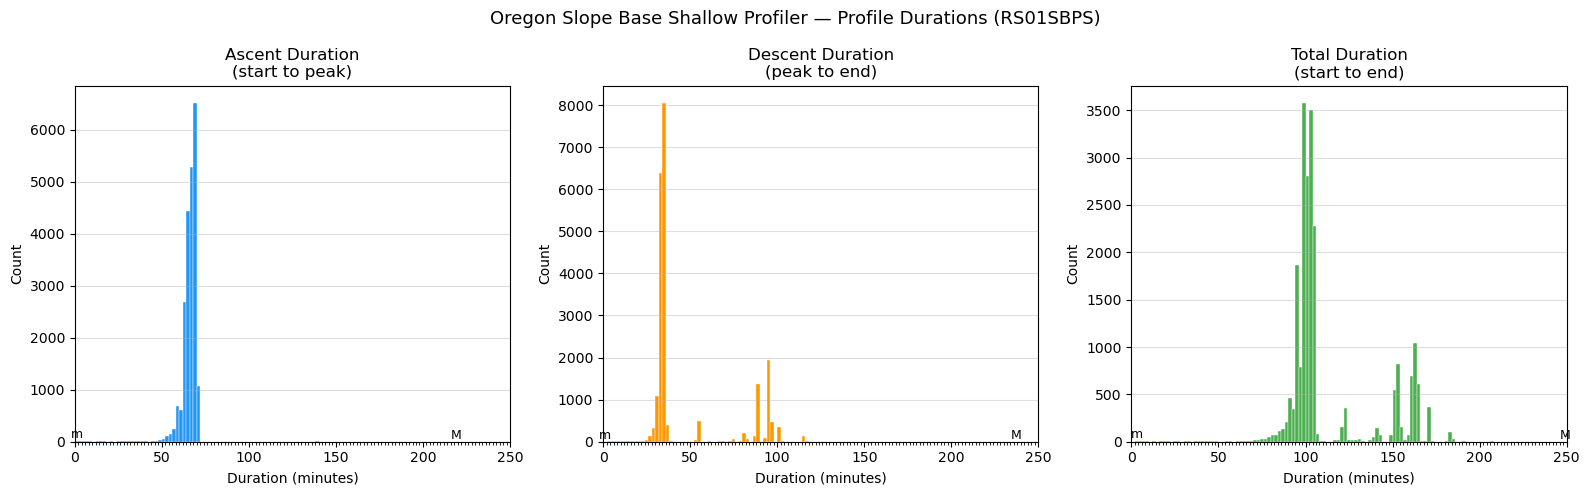

In [9]:
"""
Profile duration histograms + UTC noon/midnight verification
Oregon Slope Base shallow profiler (RS01SBPS)

Three histograms with 2-minute bin widths, x-axis fixed 0-250 minutes:
  1. Ascent duration  (start -> peak)
  2. Descent duration (peak -> end)
  3. Total duration   (start -> end)

Also writes:
  ~/argosy/profiles_midnight.csv
  ~/argosy/profiles_noon.csv

And prints a per-year summary table to stdout.
"""

import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from zoneinfo import ZoneInfo

# ── Config ────────────────────────────────────────────────────────────────────
SITE_TZ             = ZoneInfo("America/Los_Angeles")
PROFILE_INDICES_DIR = "/home/rob/ooi/profileIndices"
SITE_PATTERN        = "RS01SBPS_profiles_*.csv"
OUTPUT_PNG          = "/home/rob/argosy/SlopeBaseProfileHistograms.png"
OUT_MIDNIGHT        = "/home/rob/argosy/profiles_midnight.csv"
OUT_NOON            = "/home/rob/argosy/profiles_noon.csv"

MIN_GAP_HOURS = 20.0   # minimum separation between same-class profiles

# ── Load all RS01SBPS profileIndices files ────────────────────────────────────
files = sorted(glob.glob(f"{PROFILE_INDICES_DIR}/{SITE_PATTERN}"))
print(f"Found {len(files)} RS01SBPS profileIndices files:")
for f in files:
    print(f"  {f}")

frames = [pd.read_csv(f, parse_dates=["start", "peak", "end"]) for f in files]
pi = pd.concat(frames, ignore_index=True).sort_values("start").reset_index(drop=True)
print(f"\nTotal profiles loaded: {len(pi)}")
print(f"Date range: {pi['start'].min()} to {pi['end'].max()}")

# ── Compute durations ─────────────────────────────────────────────────────────
pi["ascent_min"]  = (pi["peak"]  - pi["start"]).dt.total_seconds() / 60.0
pi["descent_min"] = (pi["end"]   - pi["peak"] ).dt.total_seconds() / 60.0
pi["total_min"]   = (pi["end"]   - pi["start"]).dt.total_seconds() / 60.0

valid = pi[(pi["ascent_min"] > 0) & (pi["descent_min"] > 0)].copy()
print(f"Profiles with valid durations: {len(valid)}")

# ── Histogram helper ──────────────────────────────────────────────────────────
BIN_WIDTH = 2
X_MIN, X_MAX = 0, 250
BINS = np.arange(X_MIN, X_MAX + BIN_WIDTH, BIN_WIDTH)

def duration_histogram(ax, data, title, color):
    counts, edges, _ = ax.hist(data, bins=BINS, color=color,
                               edgecolor="white", linewidth=0.3)

    nonzero = [(c, e) for c, e in zip(counts, edges[:-1]) if c > 0]
    if nonzero:
        # 'm' above leftmost non-zero bin
        min_count, min_edge = min(nonzero, key=lambda x: x[1])
        ax.text(min_edge + BIN_WIDTH / 2, min_count, 'm',
                ha='center', va='bottom', fontsize=9, color='black')

        # 'M' above rightmost non-zero bin; 'M>' shifted left if beyond x-axis
        max_count, max_edge = max(nonzero, key=lambda x: x[1])
        max_center = max_edge + BIN_WIDTH / 2
        if max_center > X_MAX:
            ax.text(X_MAX - 4, max_count, 'M>', ha='center', va='bottom',
                    fontsize=9, color='black')
        else:
            ax.text(max_center, max_count, 'M', ha='center', va='bottom',
                    fontsize=9, color='black')

    ax.set_xlim(X_MIN, X_MAX)
    ax.set_title(title)
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("Count")
    ax.xaxis.set_minor_locator(plt.MultipleLocator(BIN_WIDTH))
    ax.grid(axis="y", alpha=0.4)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Oregon Slope Base Shallow Profiler — Profile Durations (RS01SBPS)", fontsize=13)

duration_histogram(axes[0], valid["ascent_min"],  "Ascent Duration\n(start to peak)",  "#2196F3")
duration_histogram(axes[1], valid["descent_min"], "Descent Duration\n(peak to end)",   "#FF9800")
duration_histogram(axes[2], valid["total_min"],   "Total Duration\n(start to end)",    "#4CAF50")

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150)
print(f"\nChart saved to {OUTPUT_PNG}")

# ── Classify profiles ─────────────────────────────────────────────────────────
def classify_peak(utc_ts):
    h = utc_ts.tz_localize("UTC").astimezone(SITE_TZ).hour
    if 11 <= h <= 13:
        return "noon"
    elif h >= 23 or h <= 1:
        return "midnight"
    return "other"

valid["peak_class"] = valid["peak"].apply(classify_peak)

# ── Build filtered noon / midnight tables ─────────────────────────────────────
def build_special_profiles(df, label):
    """
    From profiles classified as `label` by local peak hour:
      - at least MIN_GAP_HOURS between consecutive retained entries
        (enforces one per day)
    Returns DataFrame with columns: profile, start, peak, end
    """
    subset = df[df["peak_class"] == label].sort_values("start").reset_index(drop=True)

    kept = []
    last_start = None
    for _, row in subset.iterrows():
        if last_start is None or (row["start"] - last_start).total_seconds() / 3600 >= MIN_GAP_HOURS:
            kept.append(row)
            last_start = row["start"]

    return pd.DataFrame(kept)[["profile", "start", "peak", "end"]].reset_index(drop=True)

midnight_df = build_special_profiles(valid, "midnight")
noon_df     = build_special_profiles(valid, "noon")

midnight_df.to_csv(OUT_MIDNIGHT, index=False)
noon_df.to_csv(OUT_NOON, index=False)
print(f"\nWrote {len(midnight_df)} midnight profiles to {OUT_MIDNIGHT}")
print(f"Wrote {len(noon_df)} noon profiles to {OUT_NOON}")

# ── Per-year summary table ────────────────────────────────────────────────────
midnight_df["year"] = pd.to_datetime(midnight_df["start"]).dt.year
noon_df["year"]     = pd.to_datetime(noon_df["start"]).dt.year

# Count active days per year: UTC days with at least one non-noon/non-midnight profile
other_profiles = valid[valid["peak_class"] == "other"].copy()
other_profiles["utc_date"] = other_profiles["start"].dt.date
other_profiles["year"]     = other_profiles["start"].dt.year
active_days = other_profiles.groupby("year")["utc_date"].nunique()

all_years = sorted(set(midnight_df["year"]) | set(noon_df["year"]) | set(active_days.index))

print("\n── Per-year midnight / noon profile counts ──────────────────────────────")
print(f"{'Year':>6}  {'Midnight':>10}  {'Noon':>8}  {'Active Days':>12}")
print(f"{'----':>6}  {'--------':>10}  {'----':>8}  {'-----------':>12}")
total_days = 0
for yr in all_years:
    n_mid  = int((midnight_df["year"] == yr).sum())
    n_noon = int((noon_df["year"]     == yr).sum())
    n_days = int(active_days.get(yr, 0))
    total_days += n_days
    print(f"{yr:>6}  {n_mid:>10}  {n_noon:>8}  {n_days:>12}")
print(f"{'Total':>6}  {len(midnight_df):>10}  {len(noon_df):>8}  {total_days:>12}")
